# 🌾 FarmIntel — Stage 1: Crop Category Model Selection

**Task:** Multi-class classification → Top-3 Crop Category Recommendation  
**Target:** `Crop_Category` (9 classes)  
**Features:** `State`, `District`, `Season`, `Year`  
**Samples:** ~276,000 training records  

### Selection Priority
1. Highest **Top-3 Accuracy** (primary — this is a recommendation system)
2. Highest **Macro F1**
3. Highest **Weighted F1**
4. Lowest **Training Time**

> **Note:** EDA and preprocessing are already complete. This notebook contains only the model selection pipeline.

---
## 1. Imports

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.preprocessing   import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)

# Optional boosting libraries
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False
    print('⚠️  xgboost not installed — model skipped')

try:
    from lightgbm import LGBMClassifier
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print('⚠️  lightgbm not installed — model skipped')

try:
    from catboost import CatBoostClassifier
    CAT_OK = True
except ImportError:
    CAT_OK = False
    print('⚠️  catboost not installed — model skipped')

print('Imports complete')

Imports complete


---
## 2. Configuration

In [3]:
# ── Paths ────────────────────────────────────────────────────────────
DATA_DIR   = '../data/processed'
OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Experiment settings ──────────────────────────────────────────────
RANDOM_STATE  = 42
N_FOLDS       = 5
TOP_K         = 3          # Top-K accuracy
N_JOBS        = -1         # Use all CPU cores

# ── Feature / target definitions ────────────────────────────────────
CAT_FEATURES  = ['State', 'District', 'Season']
NUM_FEATURES  = ['Year']
ALL_FEATURES  = CAT_FEATURES + NUM_FEATURES
TARGET        = 'Crop_Category'

# ── Result columns (final output) ────────────────────────────────────
RESULT_COLS = [
    'Model',
    'Train Accuracy',
    'CV Accuracy',
    'Train Weighted F1',
    'CV Weighted F1',
    'CV Macro F1',
    'Top-3 Accuracy',
    'Accuracy Std',
    'Weighted F1 Std',
    'Macro F1 Std',
    'Training Time',
]

print('✅ Configuration set')
print(f'   Features : {ALL_FEATURES}')
print(f'   Target   : {TARGET}')
print(f'   CV folds : {N_FOLDS}   Top-K : {TOP_K}')

✅ Configuration set
   Features : ['State', 'District', 'Season', 'Year']
   Target   : Crop_Category
   CV folds : 5   Top-K : 3


---
## 3. Load & Prepare Data

> Loads cleaned data and prepares `X_train`, `y_train` ready for the pipeline.

In [4]:
def load_data(data_dir: str, features: list, target: str):
    """
    Load pre-processed train/test CSVs and return encoded arrays.

    Returns
    -------
    X_train, y_train, X_test, y_test : np.ndarray
    encoder     : fitted OrdinalEncoder  (for categorical columns)
    label_enc   : fitted LabelEncoder    (for target)
    classes     : list of class names in label-encoded order
    """
    cat_cols = [c for c in features if c in CAT_FEATURES]
    num_cols = [c for c in features if c in NUM_FEATURES]

    train_df = pd.read_csv(os.path.join(data_dir, 'crop_train.csv'))
    test_df  = pd.read_csv(os.path.join(data_dir, 'crop_test.csv'))

    # Ordinal-encode categorical features
    ord_enc = OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    )
    ord_enc.fit(train_df[cat_cols])

    def encode_X(df):
        X_cat = ord_enc.transform(df[cat_cols])
        X_num = df[num_cols].values.astype(float)
        return np.hstack([X_cat, X_num])

    # Label-encode target
    lbl_enc = LabelEncoder()
    lbl_enc.fit(train_df[target])

    X_train = encode_X(train_df)
    y_train = lbl_enc.transform(train_df[target])
    X_test  = encode_X(test_df)
    y_test  = lbl_enc.transform(test_df[target])

    return X_train, y_train, X_test, y_test, ord_enc, lbl_enc, lbl_enc.classes_.tolist()


X_train, y_train, X_test, y_test, ord_enc, lbl_enc, CLASSES = load_data(
    DATA_DIR, ALL_FEATURES, TARGET
)

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'Classes ({len(CLASSES)}) : {CLASSES}')
print(f'Class distribution (train):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'   {CLASSES[u]:20s}  {c:>7,}  ({c/len(y_train)*100:.1f}%)')

X_train : (276261, 4)  |  X_test : (69066, 4)
Classes (9) : ['Cash Crops', 'Cereals', 'Fiber Crops', 'Fruits', 'Oilseeds', 'Plantation Crops', 'Pulses', 'Spices', 'Vegetables']
Class distribution (train):
   Cash Crops             11,977  (4.3%)
   Cereals                72,911  (26.4%)
   Fiber Crops            11,028  (4.0%)
   Fruits                  3,366  (1.2%)
   Oilseeds               52,756  (19.1%)
   Plantation Crops        5,315  (1.9%)
   Pulses                 70,403  (25.5%)
   Spices                 25,080  (9.1%)
   Vegetables             23,425  (8.5%)


---
## 4. Helper Functions

In [6]:
# ── Top-K accuracy ───────────────────────────────────────────────────

def top_k_accuracy(y_true: np.ndarray, proba: np.ndarray, k: int = 3) -> float:
    """
    Compute Top-K accuracy from class probability matrix.

    For each sample, a prediction is correct if the true class label
    appears in the K classes with the highest predicted probability.

    Parameters
    ----------
    y_true : 1-D int array of true label indices
    proba  : 2-D float array (n_samples, n_classes)
    k      : number of top predictions to consider

    Returns
    -------
    float in [0, 1]
    """
    # argsort ascending → last k are the highest-prob classes
    top_k_indices = np.argsort(proba, axis=1)[:, -k:]   # shape (n, k)
    correct = np.any(top_k_indices == y_true.reshape(-1, 1), axis=1)
    return float(correct.mean())


# ── Single-fold evaluation ───────────────────────────────────────────

def evaluate_fold(
    model,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    k: int = TOP_K,
) -> dict:
    """
    Fit model on training fold, evaluate on validation fold.

    Returns a dict with all fold-level metrics.
    """
    model.fit(X_tr, y_tr)

    # --- Validation predictions ---
    y_pred  = model.predict(X_val)
    proba   = model.predict_proba(X_val)

    # --- Training predictions (for overfit diagnostics) ---
    y_pred_tr = model.predict(X_tr)

    return {
        'val_accuracy'   : accuracy_score(y_val, y_pred),
        'val_f1_weighted': f1_score(y_val, y_pred, average='weighted', zero_division=0),
        'val_f1_macro'   : f1_score(y_val, y_pred, average='macro',    zero_division=0),
        'val_top_k_acc'  : top_k_accuracy(y_val, proba, k=k),
        'train_accuracy' : accuracy_score(y_tr, y_pred_tr),
        'train_f1_weighted': f1_score(y_tr, y_pred_tr, average='weighted', zero_division=0),
    }


# ── Full cross-validation run ────────────────────────────────────────

def run_cross_validation(
    model_name: str,
    model,
    X: np.ndarray,
    y: np.ndarray,
    cv: StratifiedKFold,
    k: int = TOP_K,
) -> dict:
    """
    Run Stratified K-Fold CV for a single model.

    Returns an aggregated result dict (means + stds across folds).
    """
    fold_metrics = []
    t_start = time.time()

    for fold_idx, (tr_idx, val_idx) in enumerate(cv.split(X, y), start=1):
        metrics = evaluate_fold(
            model,
            X[tr_idx], y[tr_idx],
            X[val_idx], y[val_idx],
            k=k,
        )
        fold_metrics.append(metrics)

    elapsed = time.time() - t_start

    # Aggregate across folds
    keys = fold_metrics[0].keys()
    agg  = {key: np.mean([fm[key] for fm in fold_metrics]) for key in keys}
    agg_std = {
        f'{key}_std': np.std([fm[key] for fm in fold_metrics])
        for key in keys
    }

    return {
        'Model'            : model_name,
        'Train Accuracy'   : agg['train_accuracy'],
        'CV Accuracy'      : agg['val_accuracy'],
        'Train Weighted F1': agg['train_f1_weighted'],
        'CV Weighted F1'   : agg['val_f1_weighted'],
        'CV Macro F1'      : agg['val_f1_macro'],
        'Top-3 Accuracy'   : agg['val_top_k_acc'],
        'Accuracy Std'     : agg_std['val_accuracy_std'],
        'Weighted F1 Std'  : agg_std['val_f1_weighted_std'],
        'Macro F1 Std'     : agg_std['val_f1_macro_std'],
        'Training Time'    : round(elapsed, 2),
    }


# ── Results builder ──────────────────────────────────────────────────

def build_results_dataframe(all_results: list) -> pd.DataFrame:
    """
    Build and sort the final comparison DataFrame.

    Sort priority:
      1. Top-3 Accuracy   (descending)
      2. CV Macro F1      (descending)
      3. CV Weighted F1   (descending)
      4. Training Time    (ascending)
    """
    df = pd.DataFrame(all_results, columns=RESULT_COLS)
    df = df.sort_values(
        by=['Top-3 Accuracy', 'CV Macro F1', 'CV Weighted F1', 'Training Time'],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    df.index = df.index + 1   # rank starts at 1
    return df


print(' Helper functions defined')

 Helper functions defined


---
## 5. Model Registry

In [7]:
def build_model_registry(random_state: int = RANDOM_STATE, n_jobs: int = N_JOBS) -> dict:
    """
    Return an ordered dict of {model_name: unfitted estimator}.

    All estimators must implement predict_proba().
    Optional libraries (XGBoost, LightGBM, CatBoost) are included only
    if they are installed.
    """
    registry = {}

    registry['Logistic Regression'] = LogisticRegression(
        max_iter=1000,
        solver='saga',
        multi_class='multinomial',
        C=1.0,
        n_jobs=n_jobs,
        random_state=random_state,
    )

    registry['Decision Tree'] = DecisionTreeClassifier(
        max_depth=25,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )

    registry['Random Forest'] = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        class_weight='balanced_subsample',
        n_jobs=n_jobs,
        random_state=random_state,
    )

    registry['Extra Trees'] = ExtraTreesClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight='balanced_subsample',
        n_jobs=n_jobs,
        random_state=random_state,
    )

    registry['Gradient Boosting'] = GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        random_state=random_state,
    )

    if XGB_OK:
        registry['XGBoost'] = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=7,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            use_label_encoder=False,
            n_jobs=n_jobs,
            random_state=random_state,
            verbosity=0,
        )

    if LGB_OK:
        registry['LightGBM'] = LGBMClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=-1,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight='balanced',
            n_jobs=n_jobs,
            random_state=random_state,
            verbose=-1,
        )

    if CAT_OK:
        registry['CatBoost'] = CatBoostClassifier(
            iterations=400,
            learning_rate=0.05,
            depth=8,
            loss_function='MultiClass',
            eval_metric='Accuracy',
            auto_class_weights='Balanced',
            random_seed=random_state,
            verbose=0,
            thread_count=n_jobs,
        )

    return registry


MODEL_REGISTRY = build_model_registry()

print(f'{len(MODEL_REGISTRY)} models registered:')
for name in MODEL_REGISTRY:
    print(f'   • {name}')

8 models registered:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Extra Trees
   • Gradient Boosting
   • XGBoost
   • LightGBM
   • CatBoost


---
## 6. Run Model Selection Pipeline

5-fold Stratified CV → collect Top-1, Top-3, Macro F1, Weighted F1 per fold

In [8]:
cv = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

all_results = []

print(f'Running {N_FOLDS}-fold Stratified CV on {len(MODEL_REGISTRY)} models...\n')
print(f'{"Model":<22} {"Top-3 Acc":>10} {"CV Acc":>8} {"Macro F1":>9} {"Wtd F1":>8} {"Time(s)":>8}')
print('─' * 70)

for model_name, model in MODEL_REGISTRY.items():
    result = run_cross_validation(
        model_name=model_name,
        model=model,
        X=X_train,
        y=y_train,
        cv=cv,
        k=TOP_K,
    )
    all_results.append(result)
    print(
        f'{model_name:<22}'
        f' {result["Top-3 Accuracy"]:>10.4f}'
        f' {result["CV Accuracy"]:>8.4f}'
        f' {result["CV Macro F1"]:>9.4f}'
        f' {result["CV Weighted F1"]:>8.4f}'
        f' {result["Training Time"]:>8.1f}s'
    )

print('─' * 70)
print('\n Cross-validation complete')

Running 5-fold Stratified CV on 8 models...

Model                   Top-3 Acc   CV Acc  Macro F1   Wtd F1  Time(s)
──────────────────────────────────────────────────────────────────────
Logistic Regression        0.8287   0.3241    0.1323   0.2335    760.9s
Decision Tree              0.6415   0.1871    0.1692   0.2021      6.2s
Random Forest              0.6680   0.1949    0.1677   0.2084    164.7s
Extra Trees                0.6511   0.1793    0.1594   0.1946     94.8s
Gradient Boosting          0.8594   0.3741    0.2547   0.3446   3439.2s
XGBoost                    0.8593   0.3773    0.2520   0.3431    105.3s
LightGBM                   0.7643   0.2724    0.2523   0.2883    167.2s
CatBoost                   0.7721   0.2706    0.2594   0.2839    291.5s
──────────────────────────────────────────────────────────────────────

 Cross-validation complete


---
## 7. Results Table

In [9]:
results_df = build_results_dataframe(all_results)

# Format for display
display_df = results_df.copy()
pct_cols   = ['Train Accuracy', 'CV Accuracy', 'Train Weighted F1',
               'CV Weighted F1', 'CV Macro F1', 'Top-3 Accuracy',
               'Accuracy Std', 'Weighted F1 Std', 'Macro F1 Std']
for col in pct_cols:
    display_df[col] = display_df[col].map('{:.4f}'.format)
display_df['Training Time'] = display_df['Training Time'].map('{:.1f}s'.format)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
display_df

,Model,Train Accuracy,CV Accuracy,Train Weighted F1,CV Weighted F1,CV Macro F1,Top-3 Accuracy,Accuracy Std,Weighted F1 Std,Macro F1 Std,Training Time
1,Gradient Boosting,0.4073,0.3741,0.3796,0.3446,0.2547,0.8594,0.0013,0.0007,0.0014,3439.2s
2,XGBoost,0.4021,0.3773,0.3695,0.3431,0.2520,0.8593,0.0010,0.0015,0.0030,105.3s
3,Logistic Regression,0.3241,0.3241,0.2335,0.2335,0.1323,0.8287,0.0006,0.0009,0.0006,760.9s
4,CatBoost,0.2780,0.2706,0.2912,0.2839,0.2594,0.7721,0.0015,0.0017,0.0014,291.5s
5,LightGBM,0.3098,0.2724,0.3228,0.2883,0.2523,0.7643,0.0013,0.0017,0.0011,167.2s
6,Random Forest,0.3839,0.1949,0.3973,0.2084,0.1677,0.6680,0.0011,0.0012,0.0008,164.7s
7,Extra Trees,0.3579,0.1793,0.3725,0.1946,0.1594,0.6511,0.0012,0.0011,0.0012,94.8s
8,Decision Tree,0.3453,0.1871,0.3591,0.2021,0.1692,0.6415,0.0013,0.0013,0.0011,6.2s


---
## 8. Best Model Selection

In [10]:
def select_best_model(results_df: pd.DataFrame) -> pd.Series:
    """
    Select the best model row from the sorted results DataFrame.

    Because the DataFrame is already sorted by the priority order
    (Top-3 Acc → Macro F1 → Weighted F1 → Training Time),
    the first row is always the winner.
    """
    return results_df.iloc[0]


best = select_best_model(results_df)

print('=' * 58)
print('  🏆  BEST MODEL FOR STAGE-1 CROP RECOMMENDATION')
print('=' * 58)
print(f'  Model            : {best["Model"]}')
print(f'  Rank             : #1 (by selection priority)')
print()
print('  ── Cross-Validation Metrics (5-fold) ──')
print(f'  Top-3 Accuracy   : {float(best["Top-3 Accuracy"]):.4f}  ± {float(best["Accuracy Std"]):.4f}')
print(f'  CV Accuracy      : {float(best["CV Accuracy"]):.4f}  ± {float(best["Accuracy Std"]):.4f}')
print(f'  CV Macro F1      : {float(best["CV Macro F1"]):.4f}  ± {float(best["Macro F1 Std"]):.4f}')
print(f'  CV Weighted F1   : {float(best["CV Weighted F1"]):.4f}  ± {float(best["Weighted F1 Std"]):.4f}')
print()
print('  ── Training Metrics ──')
print(f'  Train Accuracy   : {float(best["Train Accuracy"]):.4f}')
print(f'  Train Weighted F1: {float(best["Train Weighted F1"]):.4f}')
print(f'  Overfit Gap (Acc): {float(best["Train Accuracy"]) - float(best["CV Accuracy"]):.4f}')
print()
print(f'  Training Time    : {best["Training Time"]}')
print('=' * 58)

  🏆  BEST MODEL FOR STAGE-1 CROP RECOMMENDATION
  Model            : Gradient Boosting
  Rank             : #1 (by selection priority)

  ── Cross-Validation Metrics (5-fold) ──
  Top-3 Accuracy   : 0.8594  ± 0.0013
  CV Accuracy      : 0.3741  ± 0.0013
  CV Macro F1      : 0.2547  ± 0.0014
  CV Weighted F1   : 0.3446  ± 0.0007

  ── Training Metrics ──
  Train Accuracy   : 0.4073
  Train Weighted F1: 0.3796
  Overfit Gap (Acc): 0.0332

  Training Time    : 3439.15


---
## 9. Visualisations

In [11]:
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#1a1a2e',
    'axes.edgecolor'   : '#333355',
    'axes.labelcolor'  : '#e0e0f0',
    'text.color'       : '#e0e0f0',
    'xtick.color'      : '#a0a0c0',
    'ytick.color'      : '#a0a0c0',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.size'        : 11,
})
ACCENT    = '#7c3aed'
ACCENT2   = '#06b6d4'
HIGHLIGHT = '#f59e0b'
GREEN     = '#10b981'
print('✅ Plot style configured')

✅ Plot style configured


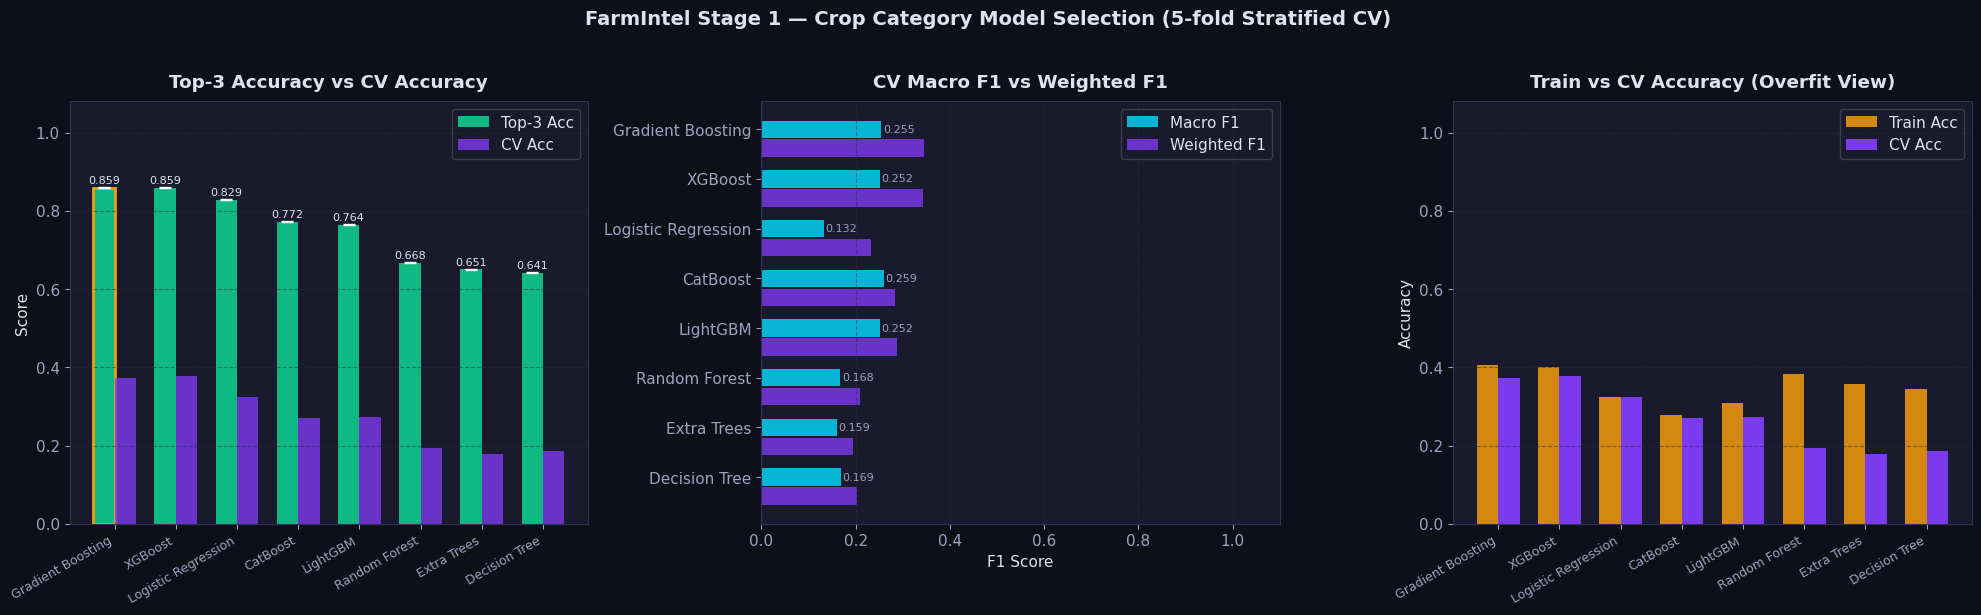

✅ Figure 1 saved


In [14]:
# ── Pull numeric values from results_df ─────────────────────────────
rdf       = results_df.copy()
m_names   = rdf['Model'].tolist()
top3_vals = rdf['Top-3 Accuracy'].astype(float).values
cv_acc    = rdf['CV Accuracy'].astype(float).values
tr_acc    = rdf['Train Accuracy'].astype(float).values
macro_f1  = rdf['CV Macro F1'].astype(float).values
wtd_f1    = rdf['CV Weighted F1'].astype(float).values
acc_std   = rdf['Accuracy Std'].astype(float).values
times     = rdf['Training Time'].astype(float).values

n = len(m_names)
x = np.arange(n)

# ── Figure 1: Main metric comparison ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (A) Top-3 vs CV Accuracy
w = 0.35
bars_top3 = axes[0].bar(x - w/2, top3_vals, w, color=GREEN,  edgecolor='none', label='Top-3 Acc')
bars_cv   = axes[0].bar(x + w/2, cv_acc,    w, color=ACCENT, edgecolor='none', label='CV Acc', alpha=0.8)
axes[0].errorbar(x - w/2, top3_vals, yerr=acc_std,
                 fmt='none', color='white', capsize=4, linewidth=1.2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(m_names, rotation=30, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel('Score')
axes[0].set_title('Top-3 Accuracy vs CV Accuracy', fontweight='bold', pad=10)
axes[0].legend(framealpha=0.2)
axes[0].grid(axis='y')
# annotate top-3 bars
for bar, v in zip(bars_top3, top3_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, color='#e0e0f0')
# highlight best
bars_top3[0].set_edgecolor(HIGHLIGHT)
bars_top3[0].set_linewidth(2)

# (B) F1 scores
colors_f1 = plt.cm.viridis(np.linspace(0.85, 0.2, n))
b_macro = axes[1].barh(m_names[::-1], macro_f1[::-1], height=0.35,
                        color=ACCENT2, edgecolor='none', label='Macro F1')
b_wtd   = axes[1].barh([i - 0.38 for i in range(n)], wtd_f1[::-1], height=0.35,
                        color=ACCENT, edgecolor='none', label='Weighted F1', alpha=0.8)
for i, (mv, wv) in enumerate(zip(macro_f1[::-1], wtd_f1[::-1])):
    axes[1].text(mv + 0.003, i, f'{mv:.3f}', va='center', fontsize=8, color='#a0a0c0')
axes[1].set_xlabel('F1 Score')
axes[1].set_title('CV Macro F1 vs Weighted F1', fontweight='bold', pad=10)
axes[1].set_xlim(0, 1.1)
axes[1].legend(framealpha=0.2)
axes[1].grid(axis='x')

# (C) Train vs CV Accuracy (overfit view)
bar_train = axes[2].bar(x - w/2, tr_acc,  w, color=HIGHLIGHT, edgecolor='none', label='Train Acc', alpha=0.85)
bar_cv2   = axes[2].bar(x + w/2, cv_acc,  w, color=ACCENT,    edgecolor='none', label='CV Acc')
axes[2].set_xticks(x)
axes[2].set_xticklabels(m_names, rotation=30, ha='right', fontsize=9)
axes[2].set_ylim(0, 1.08)
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Train vs CV Accuracy (Overfit View)', fontweight='bold', pad=10)
axes[2].legend(framealpha=0.2)
axes[2].grid(axis='y')

fig.suptitle(
    'FarmIntel Stage 1 — Crop Category Model Selection (5-fold Stratified CV)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'crop_model_selection_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('✅ Figure 1 saved')

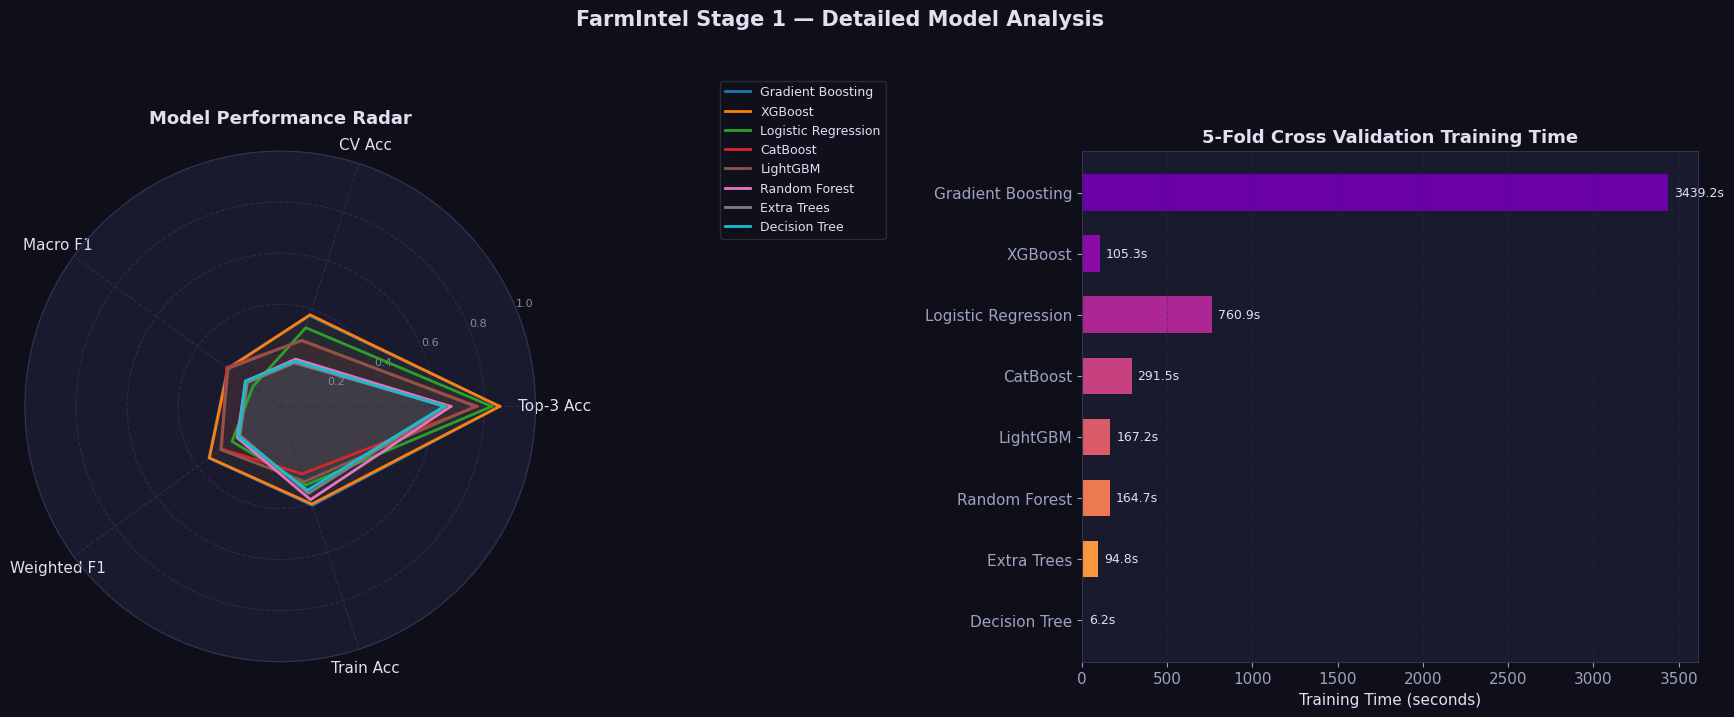

✅ Figure 2 saved successfully


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 : Radar Chart + Training Time
# ─────────────────────────────────────────────────────────────────────────────

# Make sure training time is numeric
times = rdf['Training Time'].astype(float).values

# Create figure
fig = plt.figure(figsize=(18, 7))
fig.patch.set_facecolor('#0f0f1a')

# GridSpec
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1])

# ------------------------------------------------------------------
# Radar Chart
# ------------------------------------------------------------------
ax_r = fig.add_subplot(gs[0, 0], polar=True)
ax_r.set_facecolor('#1a1a2e')

radar_keys = [
    'Top-3 Accuracy',
    'CV Accuracy',
    'CV Macro F1',
    'CV Weighted F1',
    'Train Accuracy'
]

radar_labels = [
    'Top-3 Acc',
    'CV Acc',
    'Macro F1',
    'Weighted F1',
    'Train Acc'
]

N = len(radar_keys)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

colors_radar = plt.cm.tab10(np.linspace(0, 0.9, len(rdf)))

for i, (_, row) in enumerate(rdf.iterrows()):

    values = [float(row[col]) for col in radar_keys]
    values += values[:1]

    ax_r.plot(
        angles,
        values,
        linewidth=2,
        color=colors_radar[i],
        label=row['Model']
    )

    ax_r.fill(
        angles,
        values,
        color=colors_radar[i],
        alpha=0.06
    )

ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(
    radar_labels,
    fontsize=11,
    color='#e0e0f0'
)

ax_r.set_ylim(0, 1)

ax_r.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax_r.set_yticklabels(
    ['0.2','0.4','0.6','0.8','1.0'],
    fontsize=8,
    color='#8888aa'
)

ax_r.grid(
    color='#333355',
    linestyle='--',
    alpha=0.7
)

ax_r.set_title(
    'Model Performance Radar',
    fontsize=13,
    fontweight='bold',
    pad=20,
    color='#e0e0f0'
)

ax_r.legend(
    bbox_to_anchor=(1.35,1.15),
    loc='upper left',
    fontsize=9,
    framealpha=0.15,
    labelcolor='#e0e0f0'
)

# ------------------------------------------------------------------
# Training Time
# ------------------------------------------------------------------
ax_t = fig.add_subplot(gs[0,1])
ax_t.set_facecolor('#1a1a2e')

colors_time = plt.cm.plasma(np.linspace(0.85,0.2,len(rdf)))

bars = ax_t.barh(
    rdf['Model'][::-1],
    times[::-1],
    color=colors_time,
    edgecolor='none',
    height=0.6
)

offset = max(times) * 0.01

for bar, t in zip(bars, times[::-1]):

    ax_t.text(
        t + offset,
        bar.get_y() + bar.get_height()/2,
        f'{t:.1f}s',
        va='center',
        fontsize=9,
        color='#e0e0f0'
    )

ax_t.set_xlabel(
    'Training Time (seconds)',
    fontsize=11
)

ax_t.set_title(
    '5-Fold Cross Validation Training Time',
    fontsize=13,
    fontweight='bold'
)

ax_t.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

# ------------------------------------------------------------------
# Figure Title
# ------------------------------------------------------------------
fig.suptitle(
    'FarmIntel Stage 1 — Detailed Model Analysis',
    fontsize=15,
    fontweight='bold',
    y=1.02,
    color='#e0e0f0'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        'crop_model_selection_radar.png'
    ),
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f0f1a'
)

plt.show()

print("✅ Figure 2 saved successfully")

---
## 10. Final Evaluation — Best Model on Test Set

In [21]:
def final_test_evaluation(
    model_name: str,
    model,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    y_te: np.ndarray,
    classes: list,
    k: int = TOP_K,
) -> pd.DataFrame:
    """
    Refit the selected model on the full training set,
    then evaluate on the held-out test set.
    """
    print(f'Fitting {model_name} on full training set...', end=' ', flush=True)
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0
    print(f'done in {fit_time:.1f}s')

    y_pred  = model.predict(X_te)
    proba   = model.predict_proba(X_te)

    test_acc   = accuracy_score(y_te, y_pred)
    test_mac   = f1_score(y_te, y_pred, average='macro',    zero_division=0)
    test_wtd   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    test_top_k = top_k_accuracy(y_te, proba, k=k)

    metrics = pd.DataFrame({
        'Metric': ['Test Accuracy', f'Top-{k} Accuracy', 'Macro F1', 'Weighted F1'],
        'Score' : [test_acc, test_top_k, test_mac, test_wtd],
    })
    metrics['Score'] = metrics['Score'].map('{:.4f}'.format)
    return metrics, model, proba, y_pred


best_model_name     = 'XGBoost'
best_model_instance = MODEL_REGISTRY['XGBoost']

test_metrics_df, fitted_model, test_proba, test_pred = final_test_evaluation(
    model_name=best_model_name,
    model=best_model_instance,
    X_tr=X_train, y_tr=y_train,
    X_te=X_test,  y_te=y_test,
    classes=CLASSES,
)

print(f'\n🏆  {best_model_name} — Test Set Results')
print(test_metrics_df.to_string(index=False))

Fitting XGBoost on full training set... done in 24.8s

🏆  XGBoost — Test Set Results
        Metric  Score
 Test Accuracy 0.3806
Top-3 Accuracy 0.8600
      Macro F1 0.2533
   Weighted F1 0.3454



Per-class metrics — XGBoost (Test Set):
                  Precision  Recall     F1  Support
Spices               0.3808  0.6006 0.4661     6245
Cereals              0.3898  0.5313 0.4497    18387
Pulses               0.3799  0.5396 0.4459    17499
Cash Crops           0.5268  0.1996 0.2895     2901
Vegetables           0.3572  0.1350 0.1959     6016
Oilseeds             0.3425  0.1253 0.1834    13076
Plantation Crops     0.2955  0.1060 0.1561     1377
Fiber Crops          0.2317  0.0523 0.0854     2791
Fruits               0.1304  0.0039 0.0075      774


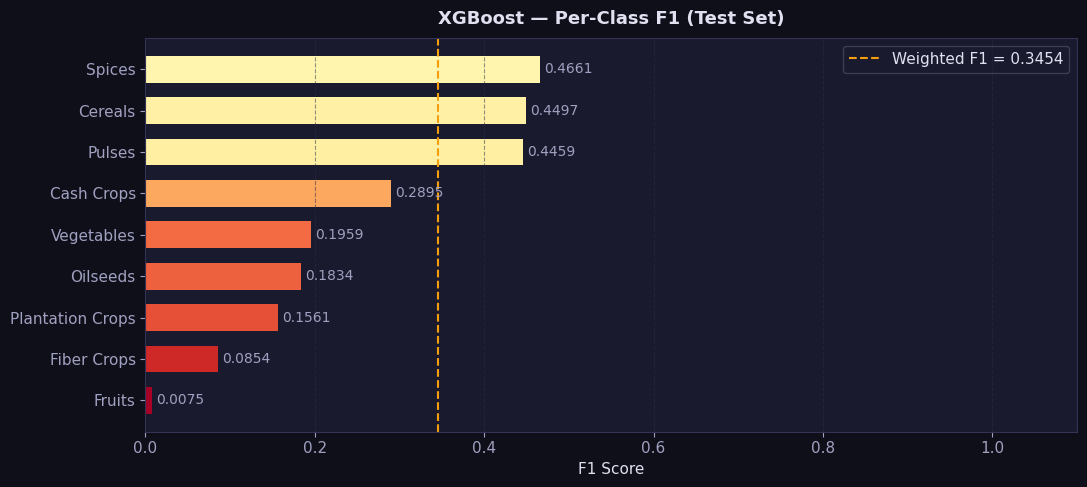

In [22]:
# ── Per-class F1 on test set ─────────────────────────────────────────
from sklearn.metrics import classification_report

report = classification_report(
    y_test, test_pred,
    target_names=CLASSES,
    zero_division=0,
    output_dict=True,
)
class_df = (
    pd.DataFrame(report).T
    .loc[CLASSES]
    .rename(columns={'f1-score': 'F1', 'precision': 'Precision',
                     'recall': 'Recall', 'support': 'Support'})
)
class_df = class_df.sort_values('F1', ascending=False)
class_df['Support'] = class_df['Support'].astype(int)

print(f'\nPer-class metrics — {best_model_name} (Test Set):')
print(class_df.to_string(float_format='{:.4f}'.format))

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
colors_pc = plt.cm.RdYlGn(class_df['F1'].values)
bars_pc = ax.barh(class_df.index[::-1], class_df['F1'].values[::-1],
                  color=colors_pc[::-1], edgecolor='none', height=0.65)
for bar, v in zip(bars_pc, class_df['F1'].values[::-1]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10, color='#a0a0c0')

overall_f1 = float(test_metrics_df[test_metrics_df['Metric']=='Weighted F1']['Score'].values[0])
ax.axvline(overall_f1, color=HIGHLIGHT, linestyle='--', linewidth=1.5,
           label=f'Weighted F1 = {overall_f1:.4f}')
ax.set_xlabel('F1 Score')
ax.set_title(f'{best_model_name} — Per-Class F1 (Test Set)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(0, 1.1)
ax.legend(framealpha=0.2)
ax.grid(axis='x')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'crop_best_model_per_class_f1.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

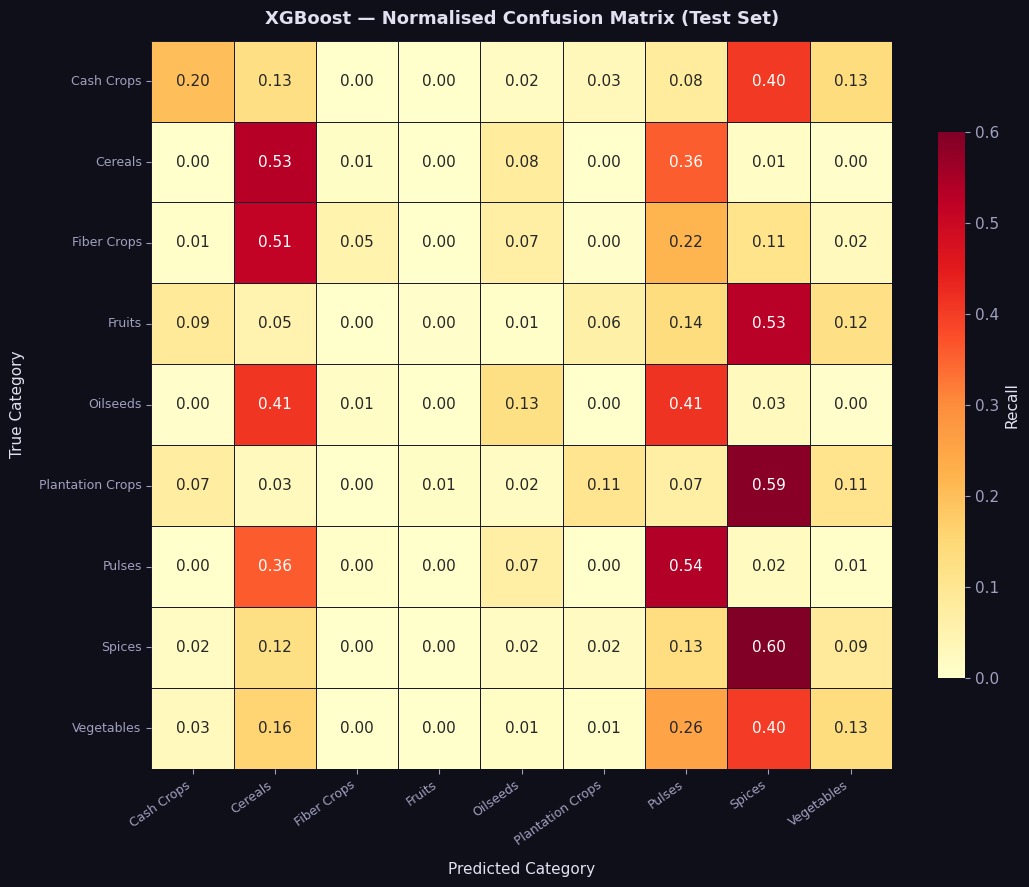

In [23]:
# ── Confusion Matrix (normalised) ────────────────────────────────────
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.4, linecolor='#1a1a2e',
    cbar_kws={'shrink': 0.75, 'label': 'Recall'},
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_xlabel('Predicted Category', labelpad=10)
ax.set_ylabel('True Category', labelpad=10)
ax.set_title(
    f'{best_model_name} — Normalised Confusion Matrix (Test Set)',
    fontsize=13, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'crop_best_model_confusion_matrix.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

---
## 11. Save Outputs

In [24]:
def save_outputs(
    results_df: pd.DataFrame,
    best_row: pd.Series,
    test_metrics_df: pd.DataFrame,
    class_df: pd.DataFrame,
    output_dir: str,
) -> None:
    """Save the results CSV and summary text file."""

    # 1) Full results CSV
    csv_path = os.path.join(output_dir, 'crop_model_selection_results.csv')
    results_df.to_csv(csv_path)
    print(f'Results CSV  → {os.path.abspath(csv_path)}')

    # 2) Summary text
    summary_path = os.path.join(output_dir, 'crop_model_selection_summary.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write('=' * 62 + '\n')
        f.write('  FARMINTEL STAGE-1 — CROP CATEGORY MODEL SELECTION SUMMARY\n')
        f.write('=' * 62 + '\n\n')
        f.write(f'Task           : Multi-class Classification\n')
        f.write(f'Target         : {TARGET} ({len(CLASSES)} classes)\n')
        f.write(f'Classes        : {CLASSES}\n')
        f.write(f'Features       : {ALL_FEATURES}\n')
        f.write(f'Train samples  : {len(y_train):,}\n')
        f.write(f'Test  samples  : {len(y_test):,}\n')
        f.write(f'CV Strategy    : StratifiedKFold ({N_FOLDS} folds)\n')
        f.write(f'Encoding       : OrdinalEncoder (cat) + numeric Year\n\n')

        f.write('── All Models (ranked by selection priority) ──\n')
        f.write(results_df.to_string() + '\n\n')

        f.write('── Best Model ──\n')
        f.write(f'Name           : {best_row["Model"]}\n')
        f.write(f'Top-3 Accuracy : {float(best_row["Top-3 Accuracy"]):.4f}\n')
        f.write(f'CV Accuracy    : {float(best_row["CV Accuracy"]):.4f}\n')
        f.write(f'CV Macro F1    : {float(best_row["CV Macro F1"]):.4f}\n')
        f.write(f'CV Weighted F1 : {float(best_row["CV Weighted F1"]):.4f}\n')
        f.write(f'Training Time  : {best_row["Training Time"]}\n\n')

        f.write('── Test Set Results (best model) ──\n')
        f.write(test_metrics_df.to_string(index=False) + '\n\n')

        f.write('── Per-Class F1 (test set) ──\n')
        f.write(class_df.to_string(float_format='{:.4f}'.format) + '\n\n')

        f.write('── Recommendations ──\n')
        f.write(f'1. Proceed to Stage-2 using {best_row["Model"]} predictions.\n')
        f.write('2. For each (State, District, Season, Year) input, extract\n')
        f.write(f'   Top-{TOP_K} predicted crop categories from predict_proba().\n')
        f.write('3. Within each category, rank crops by historical frequency.\n')
        f.write('=' * 62 + '\n')

    print(f'Summary TXT  → {os.path.abspath(summary_path)}')


save_outputs(results_df, best, test_metrics_df, class_df, OUTPUT_DIR)
print('\n✅ All outputs saved')

Results CSV  → d:\PROJECTS\AGRICULTURE\FarmIntel\ml-models-v2\outputs\crop_model_selection_results.csv
Summary TXT  → d:\PROJECTS\AGRICULTURE\FarmIntel\ml-models-v2\outputs\crop_model_selection_summary.txt

✅ All outputs saved


---
## 12. Final Summary

In [25]:
print('=' * 62)
print('  FARMINTEL STAGE-1 — MODEL SELECTION COMPLETE')
print('=' * 62)
print(f'  Models evaluated : {len(MODEL_REGISTRY)}')
print(f'  CV strategy      : StratifiedKFold (k={N_FOLDS})')
print(f'  Train samples    : {len(y_train):,}')
print(f'  Test  samples    : {len(y_test):,}')
print()
print(f'  🏆  Selected Model : {best["Model"]}')
print(f'  Top-3 Accuracy    : {float(best["Top-3 Accuracy"]):.4f}')
print(f'  CV Accuracy       : {float(best["CV Accuracy"]):.4f}')
print(f'  CV Macro F1       : {float(best["CV Macro F1"]):.4f}')
print(f'  CV Weighted F1    : {float(best["CV Weighted F1"]):.4f}')
print()
print('  📁  Saved outputs:')
print(f'  • crop_model_selection_results.csv')
print(f'  • crop_model_selection_summary.txt')
print(f'  • crop_model_selection_comparison.png')
print(f'  • crop_model_selection_radar.png')
print(f'  • crop_best_model_per_class_f1.png')
print(f'  • crop_best_model_confusion_matrix.png')
print()
print('  ➡️  Next: Stage-2 — within-category crop ranking')
print('           using historical frequencies.')
print('=' * 62)

  FARMINTEL STAGE-1 — MODEL SELECTION COMPLETE
  Models evaluated : 8
  CV strategy      : StratifiedKFold (k=5)
  Train samples    : 276,261
  Test  samples    : 69,066

  🏆  Selected Model : Gradient Boosting
  Top-3 Accuracy    : 0.8594
  CV Accuracy       : 0.3741
  CV Macro F1       : 0.2547
  CV Weighted F1    : 0.3446

  📁  Saved outputs:
  • crop_model_selection_results.csv
  • crop_model_selection_summary.txt
  • crop_model_selection_comparison.png
  • crop_model_selection_radar.png
  • crop_best_model_per_class_f1.png
  • crop_best_model_confusion_matrix.png

  ➡️  Next: Stage-2 — within-category crop ranking
           using historical frequencies.
